In [2]:
import numpy as mp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import joblib
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score



## 1. : Load the Cleaned Dataset

In [3]:
df = pd.read_csv("stroke_data_cleaned.csv")

# Separate features and target
X = df.drop('stroke', axis=1)
y = df['stroke']

## 2. : Train-Test Split

In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 3 : Handling Class Imbalance

In [5]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: stroke
0    3889
1     199
Name: count, dtype: int64
After SMOTE: stroke
0    3889
1    3889
Name: count, dtype: int64


## 4: Model Building and Training

##### 1.4.1 Logistic Regression

In [6]:
lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_train_res, y_train_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


##### 1.4.2 Random Forest Classifier

In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_res, y_train_res)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numeric_cols = X_train.select_dtypes(exclude="object").columns.tolist()


preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)


pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)

joblib.dump(pipeline, "model.pkl")
joblib.dump(X_train.columns, "columns.pkl")

['columns.pkl']

## 5.  Model Evaluation

In [9]:
models = {'Logistic Regression': lr, 'Random Forest': rf}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name} Evaluation:")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Logistic Regression Evaluation:
[[819 153]
 [ 23  27]]
              precision    recall  f1-score   support

           0       0.97      0.84      0.90       972
           1       0.15      0.54      0.23        50

    accuracy                           0.83      1022
   macro avg       0.56      0.69      0.57      1022
weighted avg       0.93      0.83      0.87      1022


Random Forest Evaluation:
[[935  37]
 [ 42   8]]
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       972
           1       0.18      0.16      0.17        50

    accuracy                           0.92      1022
   macro avg       0.57      0.56      0.56      1022
weighted avg       0.92      0.92      0.92      1022



#### Observations to note:
#### Since the dataset is imbalanced, F1-score and Recall for the stroke class are more important than Accuracy.
#### Random Forest or XGBoost usually outperform Logistic Regression in this dataset.

## 6. Hyperparameter Tuning 

In [10]:
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=25,   # number of random combinations to try
    cv=3,
    scoring='accuracy',
    n_jobs=4,
    random_state=42
)

random_search.fit(X_train, y_train)
print(random_search.best_params_)
print(random_search.best_score_)

{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': True}
0.9503422203979087


## 7. Evaluation of Tuned Model on Test Set

In [11]:
best_model = random_search.best_estimator_  # or grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]  # for ROC-AUC

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9500978473581213
Confusion Matrix:
 [[970   2]
 [ 49   1]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.33      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.64      0.51      0.51      1022
weighted avg       0.92      0.95      0.93      1022

ROC-AUC: 0.8129218106995885


## 8. Feature Importance

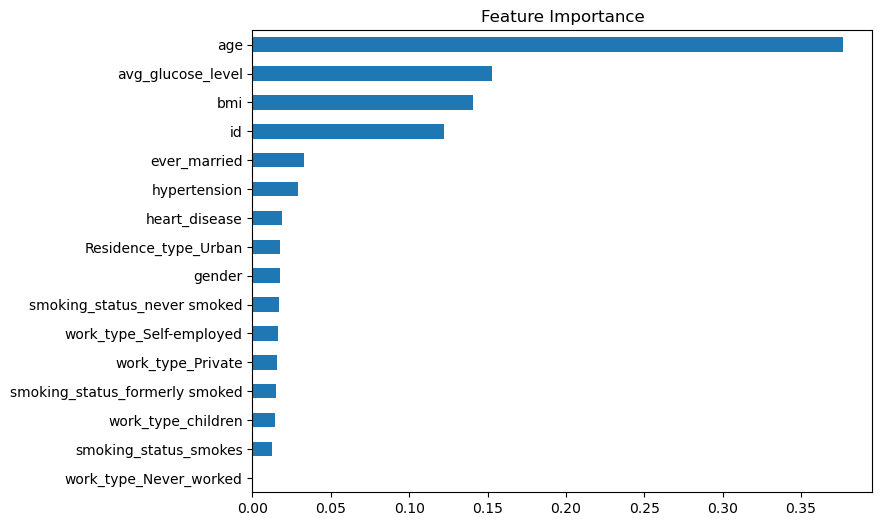

In [12]:
feature_importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
feature_importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

## 9. Correlation Heatmap

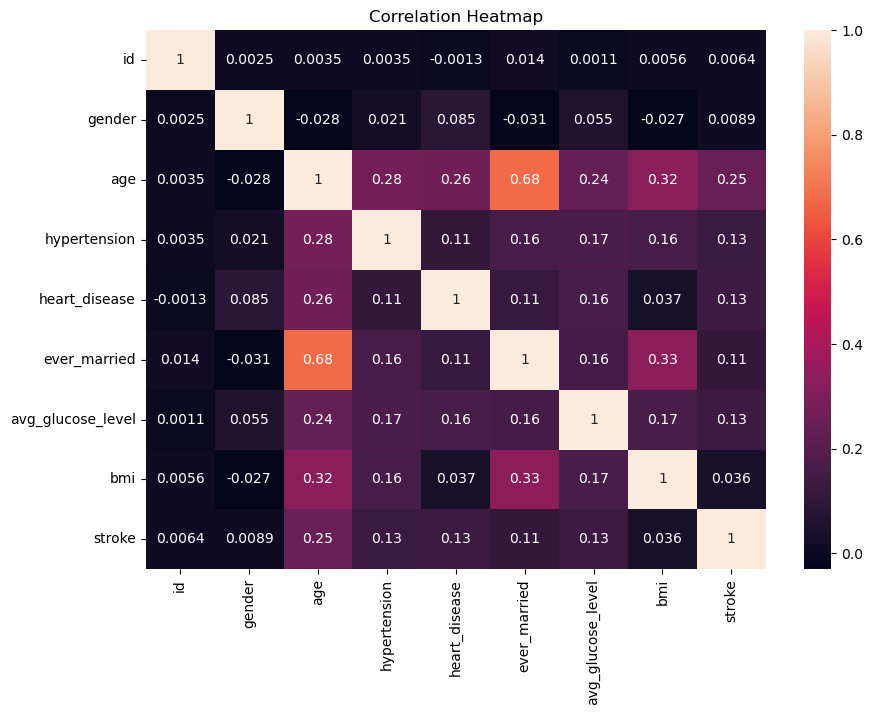

In [13]:
numerical_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numerical_df.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='rocket',  
            fmt='.2g')      

plt.title('Correlation Heatmap')
plt.show()

## 10. Confusion Matrix

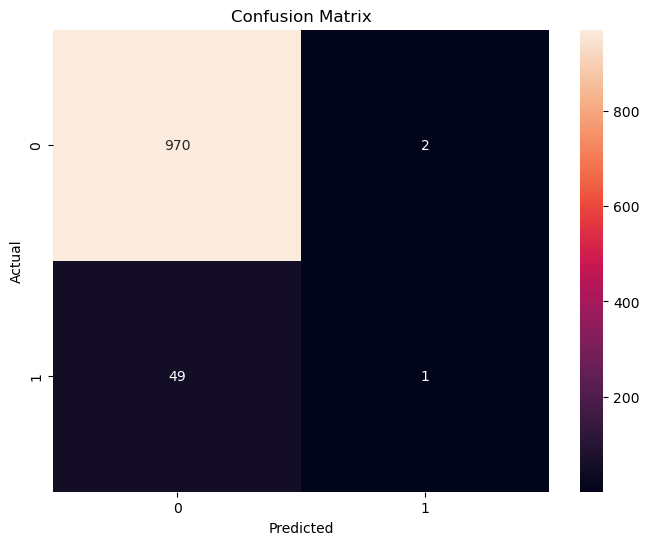

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d',        
            cmap='rocket')  
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()